In [223]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [224]:
path = "../data/bronze/bus.xlsx"


In [225]:
district = pd.read_excel(path,sheet_name=1)

In [226]:
district= district[district["0a. Has committed ESBs?"]== 'yes']

In [227]:
df_filtre = district[['3i. Percent of fleet that is electric','4b. Number of students in district','4e. Percentage of students in district eligible for free or reduced price lunch','4g. Percent of population below the poverty level']]

In [228]:
df_filtre.isna().mean() * 100

3i. Percent of fleet that is electric                                              18.922386
4b. Number of students in district                                                  3.271328
4e. Percentage of students in district eligible for free or reduced price lunch     4.233483
4g. Percent of population below the poverty level                                  12.508018
dtype: float64

In [229]:
cols = [
    "3i. Percent of fleet that is electric",
    "4b. Number of students in district",
    "4e. Percentage of students in district eligible for free or reduced price lunch",
    "4g. Percent of population below the poverty level"
]

for col in cols:
    df_filtre[col] = df_filtre[col].fillna(df_filtre[col].median())

/var/folders/gf/s4y8jpss6175xrsb0x_hpsmw0000gn/T/ipykernel_23269/4132023273.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtre[col] = df_filtre[col].fillna(df_filtre[col].median())


In [230]:
df_filtre.isna().mean() * 100

3i. Percent of fleet that is electric                                              0.0
4b. Number of students in district                                                 0.0
4e. Percentage of students in district eligible for free or reduced price lunch    0.0
4g. Percent of population below the poverty level                                  0.0
dtype: float64

In [231]:
df_filtre.head(10)

,3i. Percent of fleet that is electric,4b. Number of students in district,4e. Percentage of students in district eligible for free or reduced price lunch,4g. Percent of population below the poverty level
0,0.242424,2864.0,0.822626,0.171
1,0.125000,998.0,1.000000,0.219
3,0.166667,344.0,0.453488,0.077
29,0.500000,1291.0,0.233927,0.129
43,0.020833,5197.0,0.000000,0.031
54,0.125000,35747.0,0.440177,0.081
77,0.060606,3546.0,0.529329,0.183
80,0.057692,7742.0,0.764014,0.175
93,0.147059,23776.0,0.514048,0.146
96,0.000000,966.0,0.000000,0.129


In [232]:
features_stdr = [
    '3i. Percent of fleet that is electric',
    '4b. Number of students in district',
    '4e. Percentage of students in district eligible for free or reduced price lunch',
    '4g. Percent of population below the poverty level'

]

In [233]:
scaler = StandardScaler()

df_filtre[features_stdr] = scaler.fit_transform(df_filtre[features_stdr]) 

/var/folders/gf/s4y8jpss6175xrsb0x_hpsmw0000gn/T/ipykernel_23269/94241019.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtre[features_stdr] = scaler.fit_transform(df_filtre[features_stdr])


In [234]:
df_filtre.head(5)

,3i. Percent of fleet that is electric,4b. Number of students in district,4e. Percentage of students in district eligible for free or reduced price lunch,4g. Percent of population below the poverty level
0,0.014987,-0.262297,1.064930,0.493245
1,-0.145181,-0.330593,1.700050,1.194101
3,-0.088347,-0.354529,-0.256832,-0.879263
29,0.366324,-0.319869,-1.043010,-0.120003
43,-0.287266,-0.176909,-1.880628,-1.550916


In [ ]:
df_filtre.to_csv('clustering.csv',index=False)

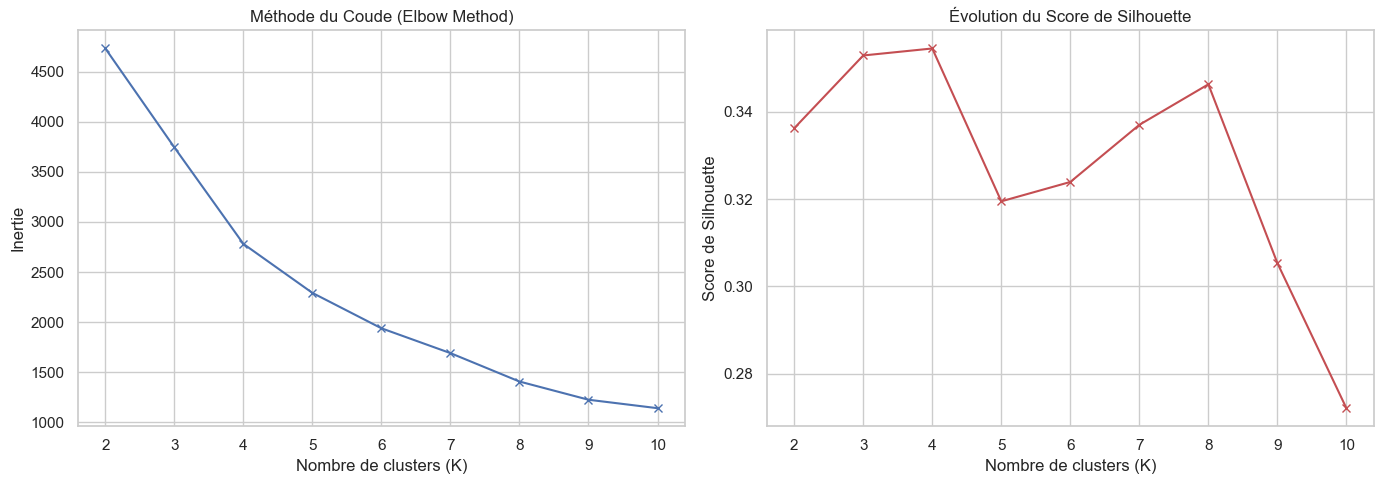

In [235]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Listes pour stocker les résultats des comparaisons
inerties = []
scores_silhouette = []
gamme_k = range(2, 11)  # On teste de 2 à 10 clusters

for k in gamme_k:
    # 1. On configure le K-means avec le hyperparamètre k actuel
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_filtre)
    
    # 2. On stocke l'inertie
    inerties.append(kmeans.inertia_)
    
    # 3. On calcule et stocke le score de silhouette
    score = silhouette_score(df_filtre, kmeans.labels_)
    scores_silhouette.append(score)

# --- Affichage des graphiques pour comparer ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Méthode du Coude
ax1.plot(gamme_k, inerties, 'bx-')
ax1.set_xlabel('Nombre de clusters (K)')
ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du Coude (Elbow Method)')

# Graphique 2 : Score de Silhouette
ax2.plot(gamme_k, scores_silhouette, 'rx-')
ax2.set_xlabel('Nombre de clusters (K)')
ax2.set_ylabel('Score de Silhouette')
ax2.set_title('Évolution du Score de Silhouette')

plt.tight_layout()
plt.show()

In [236]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. On définit la grille des paramètres qu'on veut tester
liste_k = [3, 4, 5, 6, 7 ,  8, 9]
liste_init = ['k-means++', 'random']

# Liste pour stocker nos résultats
resultats = []

# 2. La double boucle for (notre GridSearch manuel)
for k in liste_k:
    for mode_init in liste_init:
        
        # On configure le modèle avec la combinaison actuelle
        kmeans = KMeans(n_clusters=k, init=mode_init, random_state=42, n_init=10)
        labels = kmeans.fit_predict(df_filtre)
        
        # On calcule le score de Silhouette
        score = silhouette_score(df_filtre, labels)
        
        # On stocke le tout dans un dictionnaire
        resultats.append({
            'Nb_Clusters (K)': k,
            'Mode_Initialization': mode_init,
            'Silhouette_Score': score
        })

# 3. On affiche le résultat sous forme de joli tableau
df_tuning = pd.DataFrame(resultats)
print(df_tuning.sort_values(by='Silhouette_Score', ascending=False))

    Nb_Clusters (K) Mode_Initialization  Silhouette_Score
3                 4              random          0.358321
2                 4           k-means++          0.354465
1                 3              random          0.352984
0                 3           k-means++          0.352866
10                8           k-means++          0.346266
9                 7              random          0.344321
8                 7           k-means++          0.336991
7                 6              random          0.327955
6                 6           k-means++          0.323918
4                 5           k-means++          0.319487
5                 5              random          0.318455
11                8              random          0.308187
12                9           k-means++          0.305365
13                9              random          0.273020


In [278]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np

# On ré-entraîne ton meilleur modèle (ici exemple avec K=3, ajuste si tu préfères 4)
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
labels = kmeans_final.fit_predict(df_filtre)

# --- 1. Score de Silhouette Global ---
score_global = silhouette_score(df_filtre, labels)

# --- 2. Score de Silhouette par Cluster ---
valeurs_silhouette = silhouette_samples(df_filtre, labels)
scores_par_cluster = {}
for i in range(3): # 3 car K=3
    scores_par_cluster[f"Cluster {i}"] = np.mean(valeurs_silhouette[labels == i])

# --- 3. Inertie ---
inertie_finale = kmeans_final.inertia_

# --- AFFICHAGE DU RAPPORT D'ÉVALUATION ---
print("========================================")
print("      RAPPORT D'ÉVALUATION DU K-MEANS   ")
print("========================================")
print(f"Inertie Totale (Intra-cluster) : {inertie_finale:.2f}")
print(f"Score de Silhouette Global     : {score_global:.4f}")
print("----------------------------------------")
print("Qualité individuelle de chaque cluster (Silhouette) :")
for cluster, score_c in scores_par_cluster.items():
    print(f" * {cluster} : {score_c:.4f}")
print("========================================")

      RAPPORT D'ÉVALUATION DU K-MEANS   
Inertie Totale (Intra-cluster) : 3743.75
Score de Silhouette Global     : 0.3529
----------------------------------------
Qualité individuelle de chaque cluster (Silhouette) :
 * Cluster 0 : 0.3615
 * Cluster 1 : 0.2997
 * Cluster 2 : 0.3977


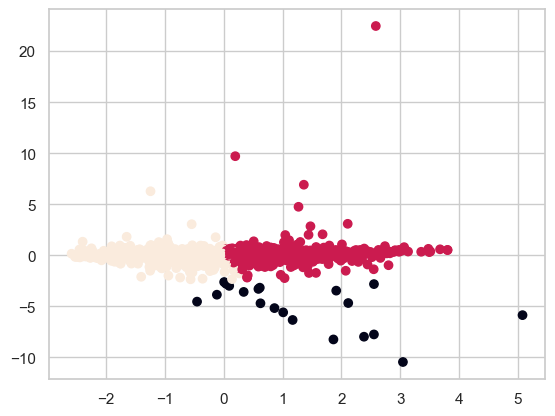

In [279]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X2 = PCA(n_components=2).fit_transform(df_filtre)

plt.scatter(
    X2[:,0],
    X2[:,1],
    c=labels
)

plt.show()